In [23]:
from high_order_infidelities import *
from qutip import *

In [24]:
def inf_rect_pulse_pert_theory(eta, n_ions, n_loops):
    Sx = jmat(n_ions/2, 'x')
    psi0 = fock(n_ions+1, 0)
    H = (psi0.dag()*Sx**8*psi0 - (psi0.dag()*Sx**4*psi0)**2
     - ((psi0.dag()*Sx**6*psi0 -  psi0.dag()*Sx**4*psi0*psi0.dag()*Sx**2*psi0)**2 /
                 (psi0.dag()*Sx**4*psi0 - (psi0.dag()*Sx**2*psi0)**2))).real
    theta_4 = 3*np.pi/8/n_loops
    g = np.pi/2*eta**2/math.sqrt(n_loops)
    Sx = jmat(n_ions/2, 'x')
    psi0 = fock(n_ions+1, 0)
    ph_ex = (psi0.dag()*Sx**6*psi0).real*abs(g)**2
    
    return (theta_4*eta**2)**2*H + ph_ex


def inf_rect_sym_pulse_pert_theory(eta, n_ions, n_loops):
    Sx = jmat(n_ions/2, 'x')
    psi0 = fock(n_ions+1, 0)
    H = (psi0.dag()*Sx**8*psi0 - (psi0.dag()*Sx**4*psi0)**2
     - ((psi0.dag()*Sx**6*psi0 -  psi0.dag()*Sx**4*psi0*psi0.dag()*Sx**2*psi0)**2 /
                 (psi0.dag()*Sx**4*psi0 - (psi0.dag()*Sx**2*psi0)**2))).real
    theta_4 = 3*np.pi/8/n_loops/2
    g = np.pi/2*eta**2/math.sqrt(n_loops)
    
    return (theta_4*eta**2)**2*H

# Get equation numbers from `main.log`

In [25]:
import re

In [26]:
with open("../latex/main.log", encoding="UTF-8", errors='ignore') as main_log_file:
    print(main_log_file)
    main_log = main_log_file.read()

<_io.TextIOWrapper name='../latex/main.log' mode='r' encoding='UTF-8'>


In [27]:
match_1 = re.search("Rectangular pulse amplitude correction: Eq\. \d.", main_log)
match_2 = re.search("Rectangular pulse optimal infidelity: Eq\. \d.", main_log)

In [28]:
amp_corr_eq_num = re.search("\d.", match_1.group()).group()
opt_inf_eq_num = re.search("\d.", match_2.group()).group()

In [29]:
print(amp_corr_eq_num, opt_inf_eq_num)

29 30


# Generate Figure `fig:rect_pulse_n_ions_dep`

In [30]:
datafile = np.load('../data/phase_res_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-03.npz')
#datafile = np.load('../data/phase_res_amplitude_dep_rect_sym_pulse_20_ions_full_ham_eta_0-03.npz')

In [31]:
rel_f_range = datafile['rel_f_range']
n_loops_arr = datafile['n_loops_arr']
phase_res_arr = datafile['phase_res_arr']

In [32]:
n_loops = 1
k = list(n_loops_arr).index(n_loops)
phase_res = phase_res_arr[k]

In [33]:
from tdse_solutions import *

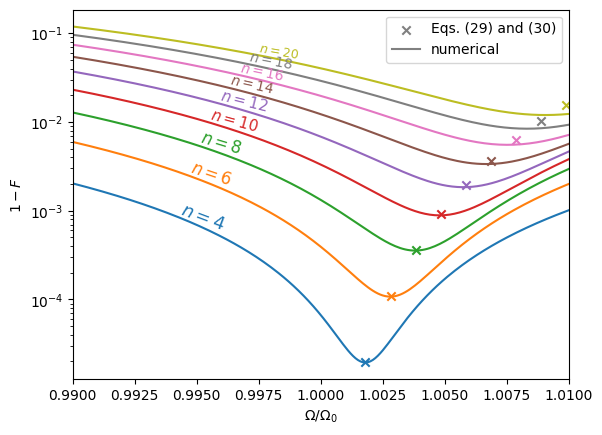

In [34]:
n_ions_max = 20
eta = 0.03
theta_4 = 3*np.pi/8/n_loops*eta**2

ymin = 2e-5
ymax = 5e1

xmin = 0.99
xmax = 1.01

data_height = np.log10(ymax) - np.log10(ymin)
data_width = xmax - xmin

for n_ions in range(4, 21, 2):  
    delta_n = int((n_ions_max - n_ions)/2)
    if delta_n == 0:
        phase_res_part = phase_res
    else:
        phase_res_part = phase_res[:,delta_n:-delta_n]
    
    inf_range = []
    
    for rel_f, pr in zip(rel_f_range, phase_res_part):
        inf = 1 - fidelity_from_phase_residuals(pr)
        inf_range.append(inf)
    l, = plt.plot(rel_f_range, inf_range)#, label=rf'$n_{{ions}}={n_ions}$')

    #print(sx4_corr_coef(n_ions))
    opt_rel_f = 1 + sx4_corr_coef(n_ions)*theta_4/np.pi + eta**2/2
    opt_inf = inf_rect_pulse_pert_theory(eta, n_ions, n_loops)

    i_text = int(35 + 2*n_ions)
    fontsize = int(14 - 0.22*n_ions)
    di = 10
    angle = np.atan(data_width/data_height*(np.log10(inf_range[i_text + di]) - np.log10(inf_range[i_text]))/(rel_f_range[i_text + di] - rel_f_range[i_text]))/np.pi*180
    #print(angle)
    plt.scatter([opt_rel_f], [opt_inf], marker='x')
    plt.text(rel_f_range[i_text], 1.1*inf_range[i_text], rf'$n={n_ions}$', 
             rotation=angle, 
             rotation_mode='anchor', 
             fontsize=fontsize,
             color=l.get_color())    

plt.scatter([], [], label=f'Eqs. ({amp_corr_eq_num}) and ({opt_inf_eq_num})', marker='x', color='gray')
plt.plot([], [], label='numerical', color='gray')
plt.xlabel(r'$\Omega/\Omega_0$')
plt.ylabel(r'$1-F$')
    
plt.yscale('log')
plt.legend()
plt.margins(x=0)
#plt.savefig('../figures/rect_pulse_fidelity_amplitude_n_ions_dep.pdf')